# 여러 영상 검색 RAG: 근거 프레임으로 OpenAI 답변 만들기

비디오 검색 RAG는 질문과 가까운 프레임 설명을 Vector DB에서 찾고, 검색된 설명만 근거로 답을 생성하는 흐름이다. 이 실습은 아홉 영상의 공통 Chroma collection을 검색하고, LLM이 선택한 `evidence_rank`를 실제 DB metadata에 연결한다.


## 전체 처리 흐름

LLM은 자연어 답변과 근거 순위만 결정한다. `video_id`, `frame_path`, `timestamp_sec`처럼 원본이 이미 알고 있는 값은 생성시키지 않는다. 이렇게 하면 자연스러운 답변과 출처 정보를 분리하여 출처 환각을 줄일 수 있다.

```mermaid
flowchart TD
    A["05의 mixkit_9_v1<br/>Chroma collection"] --> D["chunk 후보 over-fetch"]
    Q["사용자 질문"] --> B["같은 OpenAI embedding model"]
    B --> D
    D --> E["frame_id 중복 제거"]
    E --> F["rank가 붙은 top-k context"]
    F --> G["ChatOpenAI:<br/>found·answer·evidence_rank"]
    G --> H["evidence_rank 선택"]
    E --> H
    H --> I["DB metadata에서<br/>video·frame·timestamp 결정"]
    I --> J["답변·영상·근거 프레임 표시"]
```


## 실행 환경과 API 설정

05를 먼저 실행해 `mixkit_9_v1` Chroma collection을 만들어야 한다. 질문 embedding과 ChatOpenAI 답변 생성은 OpenAI API를 호출하므로 사용량에 따른 비용이 발생한다.

```bash
pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pydantic pandas pillow matplotlib
```

실제 key는 `.env`에서 불러오며 source나 출력에 표시하지 않는다. 이 교안에는 `gpt-5.6-luna`로 대표 질문과 11개 평가 질문을 실제 실행한 결과가 저장되어 있다.


In [1]:
%pip install chromadb==1.5.9 langchain-openai==1.5.2 python-dotenv==1.2.3 pydantic pandas pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


## Chroma collection과 OpenAI model 준비하기

질문 embedding은 05에서 저장한 caption embedding과 같은 model을 사용해야 한다. `MIN_SIMILARITY`는 검색 결과가 corpus와 충분히 가까운지 판단하는 수업용 기준이다. 절대적인 정답 기준이 아니므로 실제 positive·negative 결과를 관찰한 뒤 조정한다.


In [2]:


import os
from pathlib import Path

import chromadb
from dotenv import find_dotenv, load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

ENV_PATH = find_dotenv(usecwd=True)
load_dotenv(ENV_PATH)

CORPUS_ID = 'mixkit_9_v1'
ARTIFACT_ROOT = Path('artifacts/multimodal_rag') / CORPUS_ID
COMMENT_DIR = ARTIFACT_ROOT / 'comments'
VIDEO_MANIFEST_PATH = ARTIFACT_ROOT / 'video_manifest.jsonl'
FRAME_MANIFEST_PATH = ARTIFACT_ROOT / 'frame_manifest.jsonl'
CHROMA_DIR = ARTIFACT_ROOT / 'chroma'
COLLECTION_NAME = 'video_frame_descriptions_openai_mixkit9_v1'
EMBEDDING_MODEL_ID = os.getenv('OPENAI_EMBEDDING_MODEL') or 'text-embedding-3-small'
CHAT_MODEL_ID = os.getenv('OPENAI_CHAT_MODEL') or 'gpt-5.6-luna'
MIN_SIMILARITY = 0.25

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# 프레임 이미지가 54개의 설명을 임베딩해서 저장한 VectorDB Load
frame_collection = chroma_client.get_collection(name=COLLECTION_NAME)

# 사용자 입력을 임베딩 하기 위한 용도
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL_ID)

# Vector 검색 결과(근거)를 이용하여 메시지를 생성할 LLM
chat_model = ChatOpenAI(model=CHAT_MODEL_ID, reasoning_effort='low')

print(f'corpus_id={CORPUS_ID}')
print(f'collection_count={frame_collection.count()}')
print(f'embedding_model={EMBEDDING_MODEL_ID}')
print(f'chat_model={CHAT_MODEL_ID}')
print(f'min_similarity={MIN_SIMILARITY}')


corpus_id=mixkit_9_v1
collection_count=54
embedding_model=text-embedding-3-small
chat_model=gpt-5.6-luna
min_similarity=0.25


## 질문마다 서로 다른 top-k 프레임 검색하기

상세 설명 하나가 여러 chunk로 나뉘므로 필요한 결과 수보다 많은 chunk를 먼저 가져온다. 가까운 순서대로 처음 등장한 `frame_id`만 남기면 top-k가 서로 다른 실제 장면으로 구성된다.


In [3]:
def retrieve_unique_frames(question: str, top_k: int = 4, overfetch_factor: int = 5):

    question_embedding = embedding_model.embed_query(question)
    candidate_count = min(
        frame_collection.count(),
        max(top_k, top_k * overfetch_factor),
    )

    raw_result = frame_collection.query(
        query_embeddings=[question_embedding],
        n_results=candidate_count,
        include=['documents', 'metadatas', 'distances'],
    )

    results = []
    seen_frame_ids = set()
    candidates = zip(
        raw_result['ids'][0],
        raw_result['documents'][0],
        raw_result['metadatas'][0],
        raw_result['distances'][0],
    )
    for chunk_id, text, metadata, distance in candidates:
        if metadata['frame_id'] in seen_frame_ids:
            continue
        seen_frame_ids.add(metadata['frame_id'])
        results.append({
            'chunk_id': chunk_id,
            'text': text,
            'metadata': metadata,
            'distance': float(distance),
            'similarity': 1.0 - float(distance),
        })
        if len(results) == top_k:
            break
    return results

## LLM이 생성할 구조 제한하기

Structured output은 모델 응답을 정해진 필드로 제한하는 방식이다. `found`는 근거 존재 여부, `answer`는 질문에 대한 짧은 답, `evidence_rank`는 검색 결과 중 선택한 순위이다. 영상 파일명이나 프레임 경로는 LLM 출력에 포함하지 않는다.


In [4]:


from pydantic import BaseModel, Field

class RagDecision(BaseModel):

    found: bool = Field(description='검색된 설명에 질문의 답이 직접 있으면 true이다.')
    answer: str = Field(description='검색 근거만 사용한 짧은 한국어 답변이다.')
    evidence_rank: int | None = Field(
        description='found가 true이면 1부터 시작하는 근거 rank이고, false이면 null이다.'
    )

#
decision_model = chat_model.with_structured_output(RagDecision)


## 검색과 답변을 하나의 RAG 함수로 연결하기

Context에는 rank, 영상 ID, 시각과 설명 chunk를 넣어 모델이 어떤 근거를 선택했는지 밝히게 한다. 모델이 반환한 rank가 범위를 벗어나거나 top-1 similarity가 임계값보다 낮으면 근거 없음으로 처리한다. 최종 영상·프레임 정보는 선택한 검색 결과의 metadata에서 코드가 가져온다.


In [5]:
def answer_video_question(question: str, top_k: int = 4):
    # 1단계는 질문과 가까운 서로 다른 실제 프레임을 검색하는 과정이다.
    search_results = retrieve_unique_frames(question, top_k=top_k)
    context = '\n\n'.join(
        (
            f"Rank {rank}\n"
            f"video_id: {result['metadata']['video_id']}\n"
            f"timestamp_sec: {float(result['metadata']['timestamp_sec']):.2f}\n"
            f"description: {result['text']}"
        )
        for rank, result in enumerate(search_results, start=1)
    )

    # 2단계는 rank가 붙은 검색 context만 LLM에 전달해 구조화 판단을 받는 과정이다.
    decision = decision_model.invoke([
        (
            'system',
            '검색된 프레임 설명만 사용해 답한다. 답이 직접 없으면 found=false로 판단한다. '
            'found=true이면 답을 뒷받침하는 하나의 evidence_rank를 선택한다.',
        ),
        ('human', f'질문: {question}\n\n검색 결과:\n{context}'),
    ])

    # similarity 기준과 rank 범위는 LLM이 아닌 코드가 검증한다.
    valid_rank = (
        decision.evidence_rank is not None
        and 1 <= decision.evidence_rank <= len(search_results)
    )

    selected_candidate = search_results[decision.evidence_rank - 1] if valid_rank else None

    passes_threshold = (
        selected_candidate is not None
        and selected_candidate['similarity'] >= MIN_SIMILARITY
    )
    # 3단계는 LLM 판단, rank 범위와 similarity 기준이 모두 맞을 때만 근거를 채택하는 과정이다.
    found = bool(decision.found and valid_rank and passes_threshold)
    evidence = selected_candidate if found else None

    return {
        'question': question,
        'found': found, # 질문이 프레임 설명에 포함되어 있으면 True
        'answer': decision.answer if found else '검색된 프레임에서 근거를 찾지 못했다.',
        'evidence_rank': decision.evidence_rank if found else None,
        'evidence': evidence,
        'search_results': search_results,
    }

## 답변과 검색 근거 표시하기

검색 표는 LLM에 전달된 rank 순서를 그대로 사용한다. 답변 아래에는 선택된 실제 프레임과 로컬 비디오 플레이어를 표시한다. `embed=False`는 MP4 전체를 notebook output에 base64로 저장하지 않고 파일 경로를 참조한다.


In [6]:


import matplotlib.pyplot as plt
from IPython.display import Markdown, Video, display
from PIL import Image

def display_rag_result(result: dict):

    lines = [
        '| rank | video_id | timestamp | similarity | description chunk |',
        '|---:|---|---:|---:|---|',
    ]
    for rank, item in enumerate(result['search_results'], start=1):
        metadata = item['metadata']
        safe_text = item['text'].replace('|', '&#124;').replace('\n', ' ')
        lines.append(
            f"| {rank} | {metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s | "
            f"{item['similarity']:.4f} | {safe_text} |"
        )

    display(Markdown(f"**질문:** {result['question']}\n\n" + '\n'.join(lines)))
    print(f"found={result['found']}")
    print(f"answer={result['answer']}")

    if result['evidence'] is None:
        return
    metadata = result['evidence']['metadata']
    print(f"evidence_rank={result['evidence_rank']}")
    print(f"video_id={metadata['video_id']}")
    print(f"timestamp_sec={float(metadata['timestamp_sec']):.2f}")
    print(f"frame_path={metadata['frame_path']}")

    with Image.open(Path(metadata['frame_path'])) as image:
        plt.figure(figsize=(8, 4.5))
        plt.imshow(image.convert('RGB'))
        plt.axis('off')
        plt.title(f"{metadata['video_id']} | {float(metadata['timestamp_sec']):.2f}s")
        plt.show()
    display(Video(str(metadata['video_path']), embed=False, html_attributes='controls'))


## 대표 positive 질문 네 개 실행하기

Positive 질문은 corpus 안에 답이 있는 장면을 묻는다. 강아지, 요리, 서핑과 축구처럼 서로 다른 영상의 결과가 선택되는지 확인한다.


**질문:** 강아지는 입에 무엇을 물고 달리는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | soccer | 5.33s | 0.3191 | 여러 명의 축구 선수들이 인조 잔디 구장에서 공을 두고 움직이고 있다.   앞쪽에는 검은색 상의와 반바지를 입은 선수가 달리고 있으며, 가까운 곳에는 회색 상의와 검은색 반바지를 입은 선수가 서 있다.   뒤쪽에는 골대와 파란색 상의를 입은 선수가 보이고, 구장 주변은 높은 그물과 나무로 둘러싸여 있다.   카메라는 지면 가까이에서 촬영되어 앞쪽 선수와 잔디가 크게 보인다. |
| 2 | running | 6.88s | 0.3024 | 숲길 위에 한 사람이 검은색 반바지와 양말, 운동화를 착용하고 있다.   인물은 흙길을 달리며 한쪽 발을 앞으로 내딛고 다른 발을 들어 올리고 있다.   주변에는 키 큰 나무와 햇빛이 드리운 숲이 보이며, 화면에는 인물의 하반신과 운동화 밑창이 크게 강조되어 있다. |
| 3 | dog_ball | 1.04s | 0.3018 | 마당에 두 사람이 큰 검은색 개와 함께 있다.   왼쪽의 남성은 개 옆에 쪼그리고 앉아 있고, 오른쪽의 여성은 개를 향해 몸을 낮추고 있다.   뒤쪽에는 나무와 잔디, 테라스가 있는 단층 주택이 보인다.   개의 목에는 분홍색 띠가 둘러져 있으며, 햇빛과 나무 그림자가 장면에 드리워져 있다. |
| 4 | cooking | 7.80s | 0.2903 | 프라이팬 안에 다진 고기와 기름이 들어 있다.   나무 주걱이 팬 속의 고기를 저어 섞고 있다.   팬은 금속 격자와 여러 버너가 보이는 가스레인지 위에 놓여 있다.   프라이팬 가장자리는 사용 흔적처럼 어둡게 변색되어 있고, 고기 일부는 갈색으로 익어 있다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


**질문:** 요리사는 음식을 어떻게 준비하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | cooking | 7.80s | 0.2046 | 프라이팬 안에 다진 고기와 기름이 들어 있다.   나무 주걱이 팬 속의 고기를 저어 섞고 있다.   팬은 금속 격자와 여러 버너가 보이는 가스레인지 위에 놓여 있다.   프라이팬 가장자리는 사용 흔적처럼 어둡게 변색되어 있고, 고기 일부는 갈색으로 익어 있다. |
| 2 | dog_ball | 1.04s | 0.1945 | 마당에 두 사람이 큰 검은색 개와 함께 있다.   왼쪽의 남성은 개 옆에 쪼그리고 앉아 있고, 오른쪽의 여성은 개를 향해 몸을 낮추고 있다.   뒤쪽에는 나무와 잔디, 테라스가 있는 단층 주택이 보인다.   개의 목에는 분홍색 띠가 둘러져 있으며, 햇빛과 나무 그림자가 장면에 드리워져 있다. |
| 3 | dog_ball | 4.75s | 0.1927 | 검은색 큰 개가 화면 앞쪽에 서 있고, 뒤쪽에는 수염 난 남성과 긴 머리의 여성이 보인다.   여성은 풀밭에 앉아 개 쪽으로 보라색 물체를 내밀고 있으며, 개는 입을 벌린 채 여성을 향하고 있다.   장면은 나무가 있는 주택 마당으로, 뒤에는 붉은 기와 지붕과 돌벽의 집이 자리한다.   개는 분홍색 목걸이를 착용하고 있고, 여성은 파란색과 노란색 체크무늬 셔츠를 입고 있다. |
| 4 | cooking | 1.88s | 0.1814 | 프라이팬 안에 잘게 썬 양파와 고기처럼 보이는 재료가 들어 있고, 나무 주걱이 재료를 저어 주고 있다.   팬은 가스레인지 위에 놓여 있으며 아래 버너에서 파란 불꽃이 보인다.   팬 가장자리에 기름이 고여 있고 재료가 갈색빛을 띠는 모습이 특징적이다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


**질문:** 서퍼는 파도 위에서 무엇을 하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | surfing | 0.92s | 0.5239 | 바다 위에 여러 명의 서퍼가 보이며, 몇 명은 파도 위에서 서핑을 하고 있습니다.   화면 중앙과 왼쪽에는 낮은 파도가 일고 있고, 서퍼들이 그 주변에 흩어져 있습니다.   넓은 바다 뒤로 안개 낀 산 능선이 보이며, 전체적으로 흐린 하늘과 푸른 회색빛이 두드러집니다. |
| 2 | surfing | 4.17s | 0.4897 | 바다 위에 서퍼 한 명이 서핑보드를 타고 파도를 가르고 있다.   서퍼 뒤쪽으로 작은 인물이 보이며, 주변에는 넓은 바다와 부서지는 흰 파도가 펼쳐져 있다.   멀리 안개 낀 수평선 너머로 산과 해안선이 희미하게 보이고, 전체적으로 푸른빛과 회색빛이 감도는 장면이다. |
| 3 | surfing | 7.42s | 0.4591 | 바다의 큰 파도 위에 서퍼 한 명이 서핑보드를 타고 이동하고 있다.   서퍼 주변으로 흰 포말이 일며 파도가 길게 부서지고 있다.   넓은 바다 뒤로 안개 낀 해안 산지가 희미하게 보이며, 화면 왼쪽 먼 곳에는 작은 인물 하나가 떠 있다. |
| 4 | surfing | 13.89s | 0.4081 | 바다 위에서 큰 파도가 일고 있으며, 파도 중앙 부근에 작은 서퍼가 보인다.   파도는 흰 포말을 일으키며 화면 아래쪽으로 부서지고 있다.   주변은 넓은 바다이고, 뒤쪽에는 안개 낀 산 능선과 흐린 하늘이 보인다.   전체적으로 푸른 회색빛이 강하고, 하얀 파도와 포말이 화면에서 두드러진다. |

found=True
answer=서퍼는 파도 위에서 서핑보드를 타고 이동하고 있습니다.
evidence_rank=1
video_id=surfing
timestamp_sec=0.92
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/surfing/surfing_frame0000022.jpg


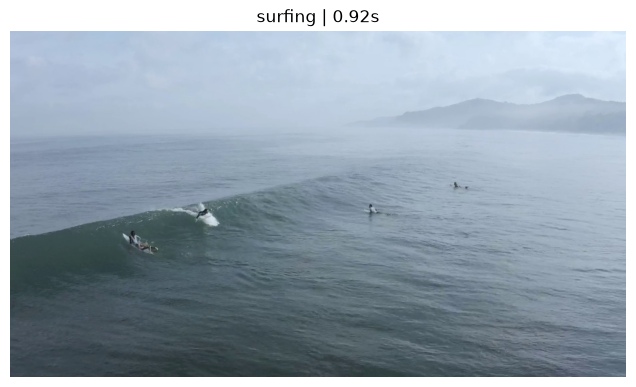

**질문:** 축구 선수는 공으로 무엇을 하고 있는가?

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | soccer | 7.70s | 0.4804 | 여러 사람이 인조잔디 축구장에서 축구를 하고 있으며, 몇 명은 골대 쪽으로 이동하고 한 사람은 팔을 들고 있다.   장면 중앙에는 흰색 축구 골대가 있고, 주변에 여러 명의 선수가 서 있거나 달리는 모습이 보인다.   경기장은 높은 그물로 둘러싸여 있으며 뒤쪽에는 나무들이 늘어서 있다.   카메라는 지면에 가까운 낮은 위치에서 촬영되어 foreground 잔디가 크게 보이고, 햇빛이 비치는 야외 장면이다. |
| 2 | soccer | 0.67s | 0.4735 | 축구장에 성인 남성 두 명이 서 있고, 한 명은 초록색 상의와 검은색 반바지를 입고 있습니다.   오른쪽의 남성은 회색 상의와 검은색 하의를 입고 있으며, 두 사람 앞쪽 바닥에는 노란색 축구공이 보입니다.   배경의 골대 앞에는 파란색 상의를 입은 또 다른 사람이 서 있습니다.   장면은 나무와 높은 그물로 둘러싸인 야외 인조 잔디 구장이며, 카메라 가까이에 있는 축구공이 크게 보이는 것이 특징입니다. |
| 3 | soccer | 3.00s | 0.4723 | 여러 명의 축구 선수와 노란색 축구공이 보인다.   선수들은 인조 잔디 위에서 공을 향해 달리거나 발을 뻗고 있으며, 가운데 뒤쪽의 선수 한 명은 서 있다.   장소는 철망으로 둘러싸인 야외 축구장이고, 뒤편에 나무와 파란색 상의를 입은 사람이 보인다.   화면 앞쪽에는 선수들의 다리와 노란 공이 크게 보이며, 공이 바닥 가까이에 위치해 있다. |
| 4 | soccer | 5.33s | 0.4139 | 여러 명의 축구 선수들이 인조 잔디 구장에서 공을 두고 움직이고 있다.   앞쪽에는 검은색 상의와 반바지를 입은 선수가 달리고 있으며, 가까운 곳에는 회색 상의와 검은색 반바지를 입은 선수가 서 있다.   뒤쪽에는 골대와 파란색 상의를 입은 선수가 보이고, 구장 주변은 높은 그물과 나무로 둘러싸여 있다.   카메라는 지면 가까이에서 촬영되어 앞쪽 선수와 잔디가 크게 보인다. |

found=True
answer=축구 선수들은 공을 향해 달리거나 발을 뻗으며 움직이고 있다.
evidence_rank=3
video_id=soccer
timestamp_sec=3.00
frame_path=artifacts/multimodal_rag/mixkit_9_v1/frames/soccer/soccer_frame0000090.jpg


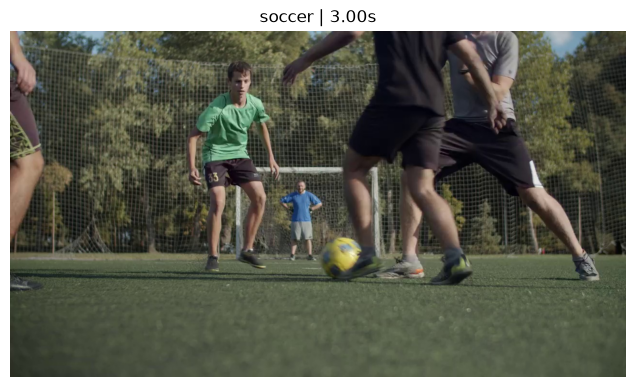

In [7]:


POSITIVE_QUESTIONS = [
    '강아지는 입에 무엇을 물고 달리는가?',
    '요리사는 음식을 어떻게 준비하고 있는가?',
    '서퍼는 파도 위에서 무엇을 하고 있는가?',
    '축구 선수는 공으로 무엇을 하고 있는가?',
]

for question in POSITIVE_QUESTIONS:

    display_rag_result(answer_video_question(question))


## Corpus에 없는 negative 질문 실행하기

Negative 질문은 저장된 아홉 영상에 없는 대상을 묻는다. 비행기 장면처럼 검색 근거가 없는 질문에서 `found=false`가 되는지 확인하고, 잘못 답한다면 `MIN_SIMILARITY`와 prompt를 positive 결과와 함께 조정한다.


In [8]:


negative_result = answer_video_question('비행기가 하늘을 날아가는 장면을 찾아줘')
display_rag_result(negative_result)


**질문:** 비행기가 하늘을 날아가는 장면을 찾아줘

| rank | video_id | timestamp | similarity | description chunk |
|---:|---|---:|---:|---|
| 1 | running | 23.11s | 0.3196 | 숲속 흙길에 한 사람이 서서 이동하고 있으며, 인물은 화면 중앙에서 멀어지는 방향으로 보인다.   주변에는 키 큰 나무들이 줄지어 있고, 길 양옆으로 풀이 있는 숲 바닥이 펼쳐져 있다.   햇빛과 나뭇가지 그림자가 길 위에 드리워져 있으며, 인물은 붉은 상의와 어두운 하의를 입고 있다. |
| 2 | surfing | 17.14s | 0.3067 | 바다에서 한 사람이 파도를 타고 있다.   사람은 화면 왼쪽 아래쪽의 부서지는 흰 파도 가장자리에 서 있다.   넓은 바다와 흐린 하늘이 보이며, 오른쪽 뒤편에는 안개 낀 해안선과 산이 이어져 있다.   전체적으로 푸른 회색빛의 흐린 분위기와 길게 굽이치는 파도가 눈에 띈다. |
| 3 | cycling | 12.35s | 0.3020 | 회색 긴소매 셔츠와 검은 바지를 입은 남성이 화면 오른쪽에 보인다.   남성은 빨간색 드롭 핸들이 달린 자전거의 핸들을 양손으로 잡고 몸을 앞으로 숙이고 있다.   금속 난간이 설치된 포장된 길 위에 있으며, 뒤쪽에는 나무와 녹색 식물이 보인다.   강한 햇빛과 난간의 그림자가 길에 드리워져 있다. |
| 4 | running | 17.68s | 0.2997 | 한 사람이 빨간 상의와 검은색 반바지를 입고 숲길을 달리고 있다.   인물은 화면 중앙에서 등을 보인 채 흙으로 된 오솔길을 따라 이동하고 있다.   주변에는 키 큰 나무들이 늘어서 있으며, 햇빛과 나뭇가지 그림자가 길 위에 드리워져 있다.   화면 아래쪽의 낮은 시점과 길게 이어지는 밝고 어두운 그림자 구간이 눈에 띈다. |

found=False
answer=검색된 프레임에서 근거를 찾지 못했다.


## 전체 corpus 질문으로 간단히 검증하기

`QUERY_CASES`는 아홉 positive와 두 negative 질문을 한 번에 확인하는 수업용 점검 목록이다. Positive는 선택된 `video_id`가 기대값과 같은지, negative는 `found=false`인지 비교한다. 이 표는 정확도를 보장하는 평가셋이 아니라 model·prompt·임계값을 조정할 작은 회귀 점검이다.


In [9]:


import pandas as pd

QUERY_CASES = [
    {'question': '강아지가 공을 물고 달리는 장면', 'expected_video_id': 'dog_ball'},
    {'question': '주방에서 음식을 요리하는 장면', 'expected_video_id': 'cooking'},
    {'question': '도로 위 자동차 교통 장면', 'expected_video_id': 'traffic'},
    {'question': '자전거를 타고 이동하는 장면', 'expected_video_id': 'cycling'},
    {'question': '야외 농구장에서 남자가 농구공을 들고 있는 장면', 'expected_video_id': 'basketball'},
    {'question': '수영하는 사람이 물속을 이동하는 장면', 'expected_video_id': 'swimming'},
    {'question': '서퍼가 파도를 타는 장면', 'expected_video_id': 'surfing'},
    {'question': '사람이 밖에서 달리는 장면', 'expected_video_id': 'running'},
    {'question': '축구 선수가 공을 차는 장면', 'expected_video_id': 'soccer'},
    {'question': '비행기가 하늘을 날아가는 장면', 'expected_video_id': None},
    {'question': '밤하늘에 불꽃놀이가 펼쳐지는 장면', 'expected_video_id': None},
]

evaluation_rows = []

for case in QUERY_CASES:
    result = answer_video_question(case['question'])
    predicted_video_id = (
        result['evidence']['metadata']['video_id']
        if result['evidence'] is not None
        else None
    )

    expected_video_id = case['expected_video_id']
    passed = (
        predicted_video_id == expected_video_id
        if expected_video_id is not None
        else result['found'] is False
    )

    evaluation_rows.append({
        'question': case['question'],
        'expected_video_id': expected_video_id,
        'found': result['found'],
        'predicted_video_id': predicted_video_id,
        'passed': passed,
    })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)
print(f"passed={int(evaluation_df['passed'].sum())}/{len(evaluation_df)}")


,question,expected_video_id,found,predicted_video_id,passed
0,강아지가 공을 물고 달리는 장면,dog_ball,False,NaN,False
1,주방에서 음식을 요리하는 장면,cooking,False,NaN,False
2,도로 위 자동차 교통 장면,traffic,True,traffic,True
3,자전거를 타고 이동하는 장면,cycling,True,cycling,True
4,야외 농구장에서 남자가 농구공을 들고 있는 장면,basketball,True,basketball,True
5,수영하는 사람이 물속을 이동하는 장면,swimming,True,swimming,True
6,서퍼가 파도를 타는 장면,surfing,True,surfing,True
7,사람이 밖에서 달리는 장면,running,True,running,True
8,축구 선수가 공을 차는 장면,soccer,True,soccer,True
9,비행기가 하늘을 날아가는 장면,NaN,False,NaN,True


passed=9/11


## Caption 기반 RAG의 범위

현재 RAG는 프레임 픽셀이 아니라 OpenAI Vision이 미리 만든 설명을 검색하고 답변한다. 따라서 설명에 기록되지 않은 작은 물체, 정확한 개수나 위치 관계는 검색과 답변 근거에서 빠질 수 있다.

`MIN_SIMILARITY`는 corpus 밖 질문을 거르는 보조 기준이며 모든 질문에 통하는 고정 정답선이 아니다. Positive와 negative 질문의 실제 점수 분포를 함께 관찰하고, 필요한 경우 캡션 prompt·검색 개수·임계값을 조정한다.
